In [19]:
from regions import Regions
from regions import CircleSkyRegion, EllipseSkyRegion
from astroquery.svo_fps import SvoFps
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy import constants as const

reg_HII = Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/resolved_HII_regions.reg')

imgfile_405410 = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/f405n_minus_f410m.fits'
imgfile_187182 = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/f187n_minus_f182m.fits'
img_for_405410 = fits.open(imgfile_405410)[0]
img_for_187182 = fits.open(imgfile_187182)[0]

image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
wcs_f187n = WCS(f187n_header)
wcs_f405n = WCS(f405n_header)

ext = CT06_MWLoc()

keys = ['density_from_paa', 'density_from_bra', 'Q_from_density_paa', 'Q_from_density_bra', 'av_estimate', 'flux_405410', 'flux_187182', 'dered_flux_405410', 'dered_flux_187182',
'EM_from_IPaa', 'EM_from_IBra', 'I_paa', 'I_bra', 'reg_radius_au']
params = {}

for reg in reg_HII:
    # get the pixel value within aperture

    # if ellipseskyregion, then change it to circleskyregion with radius = semi-major axis
    if isinstance(reg, EllipseSkyRegion):
        reg = CircleSkyRegion(center=reg.center, radius=reg.width/2, meta=reg.meta)
    reg_pix_405 = reg.to_pixel(wcs_f405n)
    reg_pix_187 = reg.to_pixel(wcs_f187n)
    mask_pix_405 = reg_pix_405.to_mask(mode='center',)
    mask_pix_187 = reg_pix_187.to_mask(mode='center',)

    cutout_405410 = mask_pix_405.cutout(img_for_405410.data)
    cutout_187182 = mask_pix_187.cutout(img_for_187182.data)
    mean_405410 = (np.nanmean(cutout_405410.data) * u.MJy/u.sr *
                   wcs_f405n.proj_plane_pixel_area()).to(u.Jy)
    mean_187182 = (np.nanmean(cutout_187182.data) * u.MJy/u.sr *
                   wcs_f187n.proj_plane_pixel_area()).to(u.Jy)
    area_mask_405 = np.pi * reg.radius**2
    area_mask_187 = np.pi * reg.radius**2
    area_mask_pix_405410 = area_mask_405 / wcs_f405n.proj_plane_pixel_area()
    area_mask_pix_187182 = area_mask_187 / wcs_f187n.proj_plane_pixel_area()
    flux_405410 = mean_405410 * area_mask_pix_405410
    flux_187182 = mean_187182 * area_mask_pix_187182

    flux_ratio = flux_405410 / flux_187182

    Adiff = 2.5*np.log10(3.9/flux_ratio.value) # intrinsic ratio of 3.9 is from the ratio of the emissivities of the two lines at 10^4 K, n_e=10^4 cm^-3, case B recombination (Storey & Hummer 1995)
    av_estimate = Adiff / (ext(1/1.87) - ext(1/4.05))

    #print('A_V estimate for region {}: {:.2f}'.format(reg.meta['text'], av_estimate))
    dered_flux_405410 = flux_405410 * 10**(0.4 * av_estimate * ext(1/4.05))
    dered_flux_187182 = flux_187182 * 10**(0.4 * av_estimate * ext(1/1.87))
    print('flux_187182:', flux_187182, 'dered_flux_187182:', dered_flux_187182, 'flux_405410:', flux_405410, 'dered_flux_405410:', dered_flux_405410)

    tab_paa = SvoFps.get_transmission_data(f'JWST/NIRCAM.f187n')
    wave_paa = tab_paa['Wavelength'] 
    trans_paa = tab_paa['Transmission']
    # get the frequency width of PaA from svo_fps
    delta_lam = np.trapezoid(trans_paa / trans_paa.max(), wave_paa) * u.AA
    print('delta_lam:', delta_lam)
    delta_nu_paa = (const.c/1.87e-6/u.m**2 * delta_lam).to(u.Hz)
    reg_radius_au = (reg.radius.value * 5400)*u.au
    I_paa = (dered_flux_187182 * delta_nu_paa / (reg.radius)**2).to(u.erg/u.s/u.cm**2/u.sr)
    EM_from_IPaa = (4*np.pi*u.sr*I_paa / (const.h*const.c/(1.87e-6*u.m)*2.59e-13*u.cm**3/u.s)).to(u.pc*u.cm**(-6))
    density_from_paa = ((EM_from_IPaa / reg_radius_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
    print('density_from_paa:', density_from_paa)
    Q_from_density_paa = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_paa**2 * reg_radius_au**3).to(u.s**-1).value) 
    print('Q_from_density_paa:', Q_from_density_paa)

    tab_bra = SvoFps.get_transmission_data(f'JWST/NIRCAM.f405n')
    wave_bra = tab_bra['Wavelength']
    trans_bra = tab_bra['Transmission']
    # get the frequency width of BrA from svo_fps
    delta_lam_bra = np.trapezoid(trans_bra / trans_bra.max(), wave_bra) * u.AA
    print('delta_lam_bra:', delta_lam_bra)
    delta_nu_bra = (const.c/4.05e-6/u.m**2 * delta_lam_bra).to(u.Hz)
    I_bra = (dered_flux_405410  * delta_nu_bra / (reg.radius)**2).to(u.erg/u.s/u.cm**2/u.sr)
    EM_from_IBra = (4*np.pi*u.sr*I_bra / (const.h*const.c/(4.05e-6*u.m)*2.59e-13*u.cm**3/u.s)).to(u.pc*u.cm**(-6))
    density_from_bra = ((EM_from_IBra / reg_radius_au/ 2)**0.5).to(u.cm**-3) #radius=fwhm
    print('density_from_bra:', density_from_bra)
    Q_from_density_bra = np.log10((4 * np.pi / 3 * 2.59e-13*u.cm**3/u.s * density_from_bra**2 * reg_radius_au**3).to(u.s**-1).value) 
    print('Q_from_density_bra:', Q_from_density_bra)

    inputs = [density_from_paa, density_from_bra, Q_from_density_paa, Q_from_density_bra, av_estimate, flux_405410, flux_187182, dered_flux_405410, dered_flux_187182,
    EM_from_IPaa, EM_from_IBra, I_paa, I_bra, reg_radius_au]
    for key, value in zip(keys, inputs):
        if key not in params:
            params[key] = []
        if isinstance(value, u.Quantity):
            params[key].append(value.value)
        else:
            params[key].append(value)
    

    








Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202550 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191894.941 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dus

flux_187182: 4874375.916555516 arcsec2 Jy / deg2 dered_flux_187182: 19736865.640097108 arcsec2 Jy / deg2 flux_405410: 8094530.8857059805 arcsec2 Jy / deg2 dered_flux_405410: 13955934.032443527 arcsec2 Jy / deg2
delta_lam: 236.59542237910327 Angstrom
density_from_paa: 0.44369179043918033 1 / cm3
Q_from_density_paa: 41.599180579118425
delta_lam_bra: 454.94571260238206 Angstrom
density_from_bra: 0.5173665832983403 1 / cm3
Q_from_density_bra: 41.73261454132598
flux_187182: 564136.4630273908 arcsec2 Jy / deg2 dered_flux_187182: 1945601.719800619 arcsec2 Jy / deg2 flux_405410: 1033242.1563798964 arcsec2 Jy / deg2 dered_flux_405410: 1673498.1094847363 arcsec2 Jy / deg2
delta_lam: 236.59542237910327 Angstrom
density_from_paa: 1.20185022858288 1 / cm3
Q_from_density_paa: 40.592956335961674
delta_lam_bra: 454.94571260238206 Angstrom
density_from_bra: 1.545655174530635 1 / cm3
Q_from_density_bra: 40.811480859469185
flux_187182: 229689.59599325113 arcsec2 Jy / deg2 dered_flux_187182: 308652.992747

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


flux_187182: 91317106.37933971 arcsec2 Jy / deg2 dered_flux_187182: 57120722.7715615 arcsec2 Jy / deg2 flux_405410: 474253999.78414553 arcsec2 Jy / deg2 dered_flux_405410: 395045218.14152163 arcsec2 Jy / deg2
delta_lam: 236.59542237910327 Angstrom
density_from_paa: 0.15061359768785965 1 / cm3
Q_from_density_paa: 42.06069608858365
delta_lam_bra: 454.94571260238206 Angstrom
density_from_bra: 0.5492465777437712 1 / cm3
Q_from_density_bra: 43.18450244259809
flux_187182: 202073.1751422264 arcsec2 Jy / deg2 dered_flux_187182: 77736.17514896873 arcsec2 Jy / deg2 flux_405410: 1412083.2537487103 arcsec2 Jy / deg2 dered_flux_405410: 973333.8684252297 arcsec2 Jy / deg2
delta_lam: 236.59542237910327 Angstrom
density_from_paa: 0.2320039815827882 1 / cm3
Q_from_density_paa: 39.19452556271806
delta_lam_bra: 454.94571260238206 Angstrom
density_from_bra: 1.1383908365919593 1 / cm3
Q_from_density_bra: 40.57611746887129
flux_187182: 29772645.15774704 arcsec2 Jy / deg2 dered_flux_187182: 60261602.09731556

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


[np.float64(0.44369179043918033), np.float64(1.20185022858288), np.float64(0.8087133431232278), np.float64(0.12886741053109446), np.float64(0.15061359768785965), np.float64(0.2320039815827882), np.float64(0.24084773633941833), np.float64(0.5912071181411331), np.float64(0.13985112478133277)]


Text(0, 0.5, 'Number of HII regions')

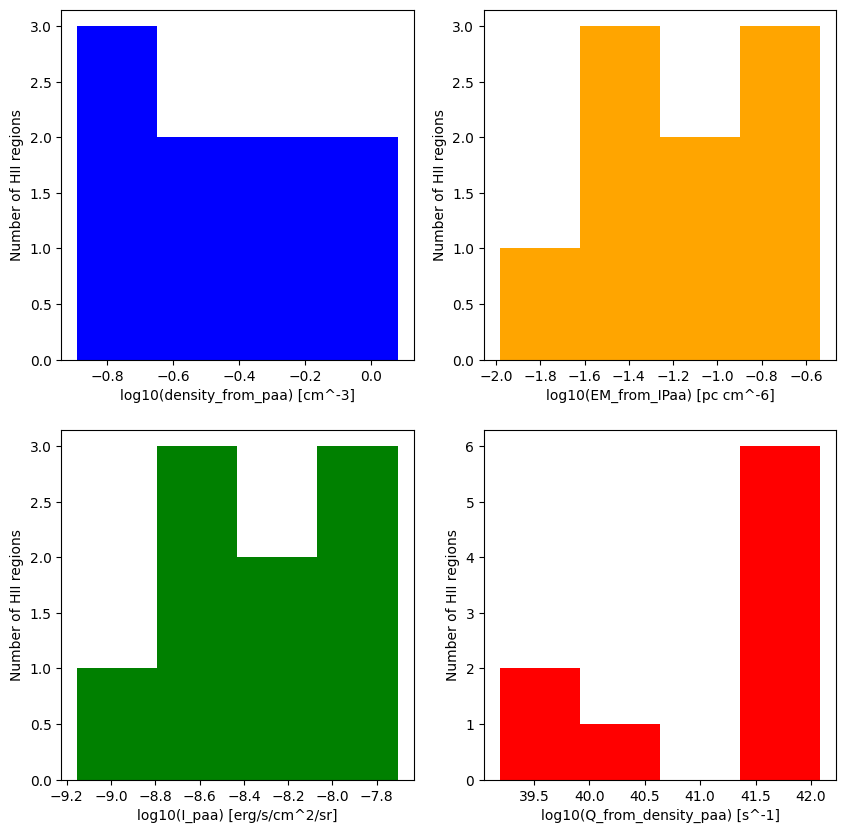

In [25]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
print(params['density_from_paa'])
ax1.hist(np.log10(params['density_from_paa']), bins=np.linspace(np.nanmin(np.log10(params['density_from_paa'])), np.nanmax(np.log10(params['density_from_paa'])), 5), color='blue')
ax1.set_xlabel('log10(density_from_paa) [cm^-3]')
ax1.set_ylabel('Number of HII regions')
ax2.hist(np.log10(params['EM_from_IPaa']), bins=np.linspace(np.nanmin(np.log10(params['EM_from_IPaa'])), np.nanmax(np.log10(params['EM_from_IPaa'])), 5), color='orange')
ax2.set_xlabel('log10(EM_from_IPaa) [pc cm^-6]')
ax2.set_ylabel('Number of HII regions')
ax3.hist(np.log10(params['I_paa']), bins=np.linspace(np.nanmin(np.log10(params['I_paa'])), np.nanmax(np.log10(params['I_paa'])), 5), color='green')
ax3.set_xlabel('log10(I_paa) [erg/s/cm^2/sr]')
ax3.set_ylabel('Number of HII regions')
ax4.hist(params['Q_from_density_paa'], bins=np.linspace(np.nanmin(params['Q_from_density_paa']), np.nanmax(params['Q_from_density_paa']), 5), color='red')
#ax4.set_xscale('log')
ax4.set_xlabel('log10(Q_from_density_paa) [s^-1]')
ax4.set_ylabel('Number of HII regions')

Text(0, 0.5, 'Number of HII regions')

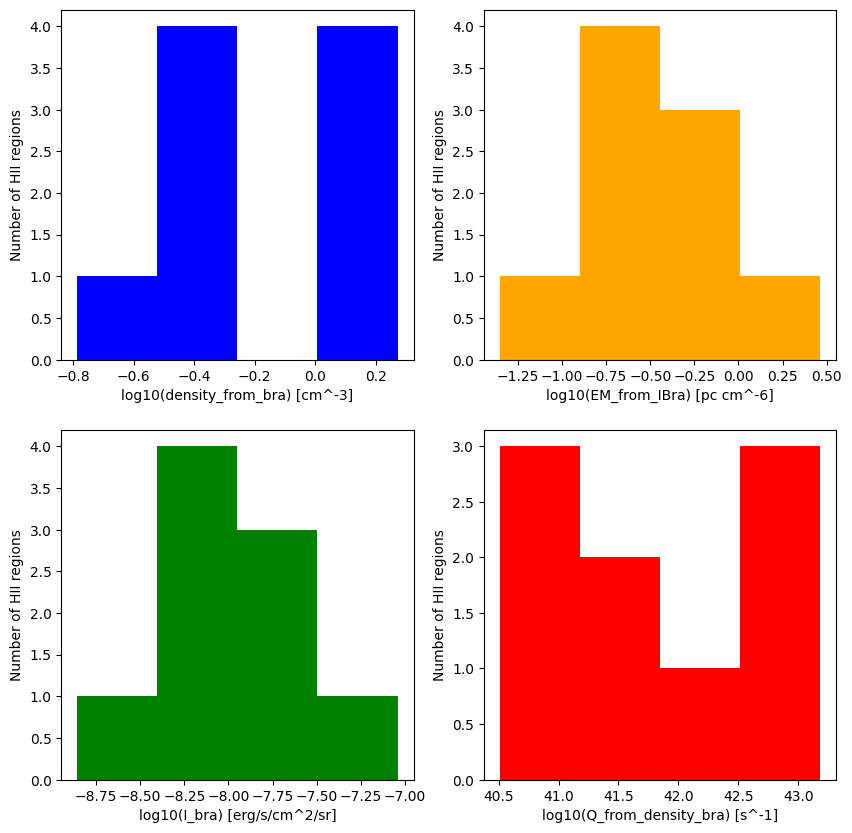

In [26]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(221)
ax2 = fig.add_subplot(222)
ax3 = fig.add_subplot(223)
ax4 = fig.add_subplot(224)
ax1.hist(np.log10(params['density_from_bra']), bins=np.linspace(np.nanmin(np.log10(params['density_from_bra'])), np.nanmax(np.log10(params['density_from_bra'])), 5), color='blue')
ax1.set_xlabel('log10(density_from_bra) [cm^-3]')
ax1.set_ylabel('Number of HII regions')
ax2.hist(np.log10(params['EM_from_IBra']), bins=np.linspace(np.nanmin(np.log10(params['EM_from_IBra'])), np.nanmax(np.log10(params['EM_from_IBra'])), 5), color='orange')
ax2.set_xlabel('log10(EM_from_IBra) [pc cm^-6]')
ax2.set_ylabel('Number of HII regions')
ax3.hist(np.log10(params['I_bra']), bins=np.linspace(np.nanmin(np.log10(params['I_bra'])), np.nanmax(np.log10(params['I_bra'])), 5), color='green')
ax3.set_xlabel('log10(I_bra) [erg/s/cm^2/sr]')
ax3.set_ylabel('Number of HII regions')
ax4.hist(params['Q_from_density_bra'], bins=np.linspace(np.nanmin(params['Q_from_density_bra']), np.nanmax(params['Q_from_density_bra']), 5), color='red')
#ax4.set_xscale('log')
ax4.set_xlabel('log10(Q_from_density_bra) [s^-1]')
ax4.set_ylabel('Number of HII regions')

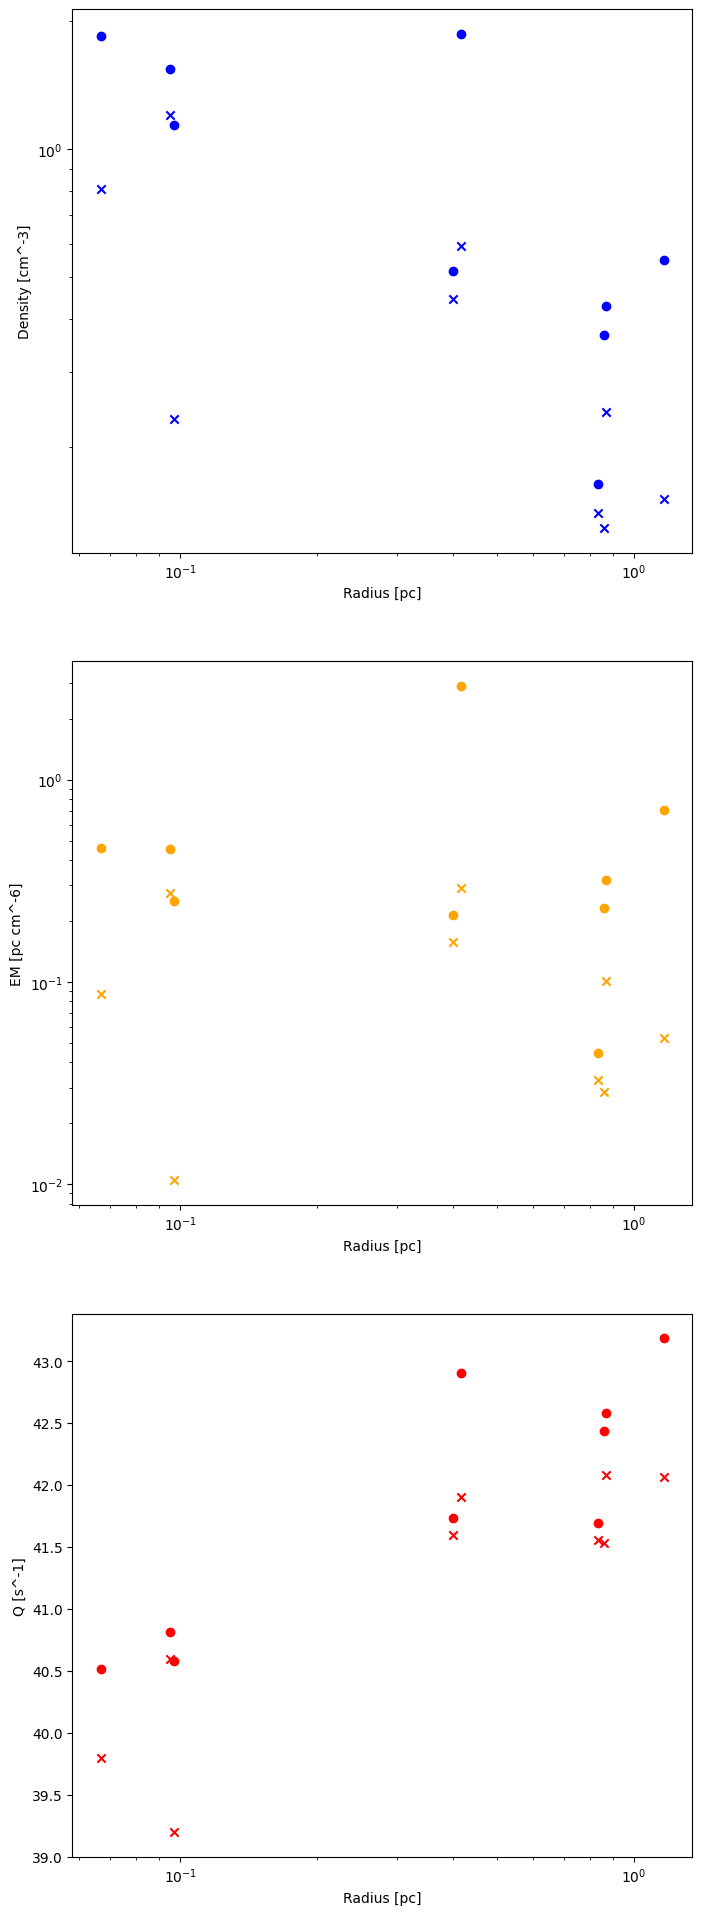

In [30]:
fig = plt.figure(figsize=(8, 24))
ax1 = fig.add_subplot(311)
ax1.scatter((params['reg_radius_au']*u.au).to(u.pc), params['density_from_bra'], color='blue')
ax1.scatter((params['reg_radius_au']*u.au).to(u.pc), params['density_from_paa'], color='blue',marker='x')
ax1.set_xlabel('Radius [pc]')
ax1.set_ylabel('Density [cm^-3]')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax2 = fig.add_subplot(312)
ax2.scatter((params['reg_radius_au']*u.au).to(u.pc), params['EM_from_IBra'], color='orange')
ax2.scatter((params['reg_radius_au']*u.au).to(u.pc), params['EM_from_IPaa'], color='orange',marker='x')
ax2.set_xlabel('Radius [pc]')
ax2.set_ylabel('EM [pc cm^-6]')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax3 = fig.add_subplot(313)
ax3.scatter((params['reg_radius_au']*u.au).to(u.pc), params['Q_from_density_bra'], color='red')
ax3.scatter((params['reg_radius_au']*u.au).to(u.pc), params['Q_from_density_paa'], color='red',marker='x')
ax3.set_xlabel('Radius [pc]')
ax3.set_ylabel('Q [s^-1]')
ax3.set_xscale('log')
#ax3.set_yscale('log')